# Robust likelihoods: Student-t versus the multivariate normal

A few gross outliers make a Gaussian fit confidently wrong.  The good news is
that the likelihood *functional* is a drop-in choice in `rxmc`: we keep the
covariance exactly as it is, swap the
[multivariate normal](https://en.wikipedia.org/wiki/Multivariate_normal_distribution)
for a [multivariate Student-t](https://en.wikipedia.org/wiki/Multivariate_t-distribution)
with a sampled tail parameter, and the fit widens instead of breaking.

That is one of two honest answers to an outlier.  The other is to decide the
point does not belong to the measurement at all and reject it, which we do at
the end, in the outer loop of recipe 39.  If instead we suspect the *errors* are
larger than stated, that is a different question, and it has its own notebook
next door (`error_scale_and_usu`).

Recipes: 9, 39

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from scipy import stats

import rxmc as rx

plotstyle.use()

## A clean signal with a few gross outliers

We will sample twenty-five points around the true line with 5 % noise, but then
also add three more points pushed up by ten times their error.  This could stand
in for, say, a background the experiment did not subtract.

In [2]:
rng = np.random.default_rng(21)
m_true, b_true = 1.0, 0.5
x = np.linspace(0.0, 4.0, 25)
noise = 0.05
y = m_true * x + b_true + rng.normal(0.0, noise, x.size)
outliers = np.array([5, 12, 19])
y[outliers] += np.array([10.0, 12.0, 9.0]) * noise
data = rx.Dataset(x, y, np.full(x.size, noise), label="with outliers")
data

Dataset('with outliers', n=25)

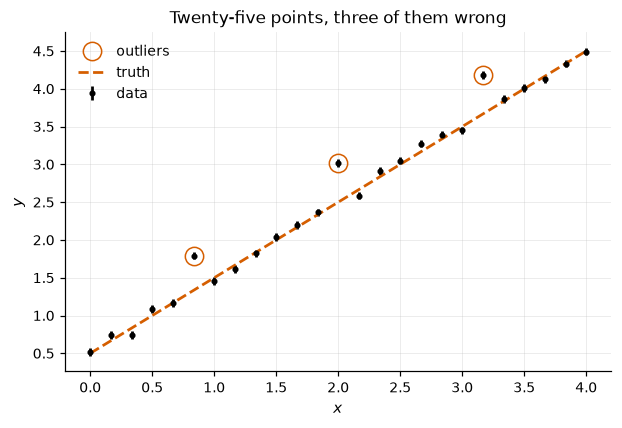

In [3]:
fig, ax = plt.subplots()
ax.errorbar(data.x, data.y, data.y_err, fmt=".", ms=6, color="k", label="data")
ax.plot(
    x[outliers],
    y[outliers],
    "o",
    ms=12,
    mfc="none",
    color=plotstyle.COLOURS[1],
    label="outliers",
)
ax.plot(x, m_true * x + b_true, "--", color=plotstyle.COLOURS[1], label="truth")
ax.set(xlabel="$x$", ylabel="$y$", title="Twenty-five points, three of them wrong")
ax.legend()
plt.show()

## The same constraint, two likelihood functionals

`rx.StudentT(nu)` applies one radial tail to the whole stacked residual of the
constraint, and $\nu$ is an ordinary parameter with its bounds and prior on the
`Parameter`, so it is simply one more column of the chain.  Everything else —
the data, the comparison, the covariance — is untouched between the two fits.

In [4]:
m = rx.Parameter("m", prior=stats.norm(1.0, 1.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(0.0, 1.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
comp = rx.Comparison(data, line)
nu = rx.Parameter("nu", bounds=(1.0, 100.0), latex=r"\nu")  # uniform on its bounds

p_gauss = rx.Problem([rx.Constraint([comp])])
p_t = rx.Problem([rx.Constraint([comp], likelihood=rx.StudentT(nu))])
print("Gaussian :", p_gauss.names)
print("Student-t:", p_t.names)

Gaussian : ['m', 'b']
Student-t: ['m', 'b', 'nu']


In [5]:
def fit(problem, seed, n_walkers=24, n_steps=2000):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)

In [6]:
s_gauss, s_t = fit(p_gauss, 1), fit(p_t, 2)

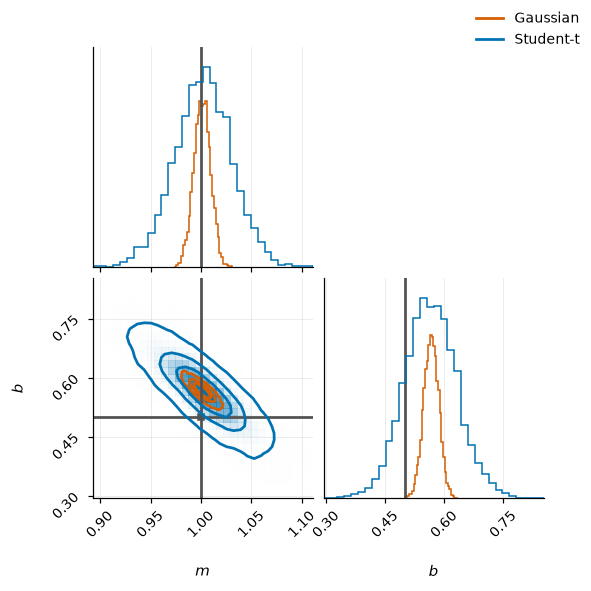

In [7]:
fig = corner.corner(
    s_gauss,
    labels=["$m$", "$b$"],
    truths=[m_true, b_true],
    **plotstyle.corner_kwargs(
        color=plotstyle.COLOURS[1], show_titles=False, fill_contours=False
    ),
)
corner.corner(
    s_t[:, p_t.columns(line.params)],
    fig=fig,
    **plotstyle.corner_kwargs(
        color=plotstyle.COLOURS[0], show_titles=False, fill_contours=False
    ),
)
fig.legend(
    handles=[
        plt.Line2D([], [], color=plotstyle.COLOURS[1], label="Gaussian"),
        plt.Line2D([], [], color=plotstyle.COLOURS[0], label="Student-t"),
    ],
    loc="upper right",
)
plt.show()

In [8]:
for name, p, s in (("Gaussian", p_gauss, s_gauss), ("Student-t", p_t, s_t)):
    cols = p.columns(line.params)
    pull = (s[:, cols].mean(0) - [m_true, b_true]) / s[:, cols].std(0)
    print(
        f"{name:10s} m = {s[:, cols[0]].mean():.3f} +/- {s[:, cols[0]].std():.3f}, "
        f"b = {s[:, cols[1]].mean():.3f} +/- {s[:, cols[1]].std():.3f}; "
        f"truth at {np.abs(pull).max():.1f} sigma"
    )

Gaussian   m = 1.001 +/- 0.008, b = 0.567 +/- 0.019; truth at 3.5 sigma
Student-t  m = 1.002 +/- 0.029, b = 0.566 +/- 0.067; truth at 1.0 sigma


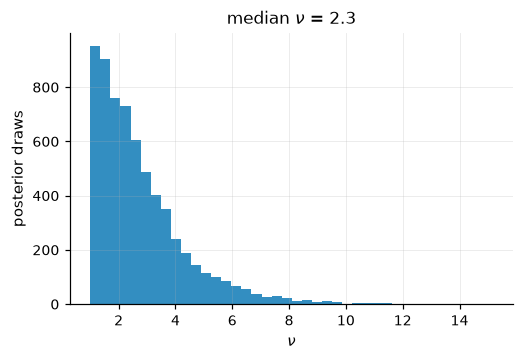

In [9]:
nu_col = p_t.columns(nu)
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.hist(s_t[:, nu_col], bins=40, color=plotstyle.COLOURS[0], alpha=0.8)
ax.set(
    xlabel=r"$\nu$",
    ylabel="posterior draws",
    title=rf"median $\nu$ = {np.median(s_t[:, nu_col]):.1f}",
)
plt.show()

Notice that, while both likelihoods have $b$ shifted upwards by the outliers,
the Student-t has inflated uncertainties which cover the true $b$, while the
Gaussian has very little posterior weight on the truth.  The small $\nu$ is the
fit telling us it needed the tail.

Note what it does *not* do: it does not reject the outliers, it widens.  Throwing
a point away is a different decision, and we come back to it at the end of this
notebook.

### $\chi^2$ is the same for both

The covariance is shared, so the $\chi^2$ must be the same between likelihood
functions.  The only difference between the likelihoods is that they are
different *functions of the $\chi^2$* (or, more accurately, of the
[Mahalanobis distance](https://en.wikipedia.org/wiki/Mahalanobis_distance)).

In [10]:
theta = np.array([m_true, b_true])
print(
    f"chi2 at the truth: Gaussian {p_gauss.chi2(theta):.2f}, "
    f"Student-t {p_t.chi2(np.append(theta, 5.0)):.2f}"
)

chi2 at the truth: Gaussian 322.62, Student-t 322.62


In [11]:
x_fine = np.linspace(-0.5, 4.5, 60)
on_fine = line.bind(x_fine)
on_data = line.bind(x)
y_true_fine = on_fine(m_true, b_true)
y_true_data = on_data(m_true, b_true)


def residual_band(problem, samples, levels=(5, 95)):
    """The fitted line's band, as a residual to the truth."""
    lo, hi = rx.predictive.grid_draws(
        problem, on_fine, x_fine, samples[::10], model_only=True, levels=levels
    )
    return lo - y_true_fine, hi - y_true_fine

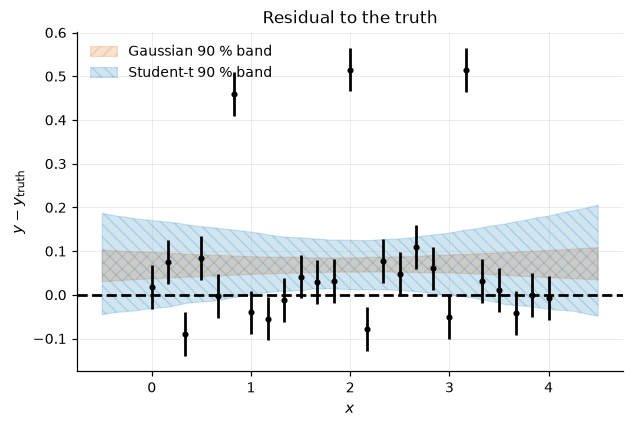

In [12]:
fig, ax = plt.subplots()
for name, p, s, colour, hatch in (
    ("Gaussian", p_gauss, s_gauss, plotstyle.COLOURS[1], plotstyle.HATCHES[0]),
    ("Student-t", p_t, s_t, plotstyle.COLOURS[0], plotstyle.HATCHES[1]),
):
    lo, hi = residual_band(p, s)
    plotstyle.band(
        ax, x_fine, lo, hi, color=colour, hatch=hatch, label=f"{name} 90 % band"
    )
ax.errorbar(data.x, data.y - y_true_data, data.y_err, fmt="o", ms=3, color="k")
ax.axhline(0.0, ls="--", color="k")
ax.set(xlabel="$x$", ylabel=r"$y - y_\mathrm{truth}$", title="Residual to the truth")
ax.legend()
plt.show()

Both are shifted relative to the truth, but the Student-t's longer tails allow
for the truth to (mostly) be covered by the 90 % credible band of the line.
These bands are the model alone: they say where each fit puts the true curve,
not where a new measurement would land.

## Rejecting the outliers instead (recipe 39)

The Student-t keeps every point and widens.  The other honest answer is to say
that those three points are not measurements of our signal at all, and to throw
them out — which is what KDUQ does, rejecting points more than $3\sigma$ from
the current model ([Pruitt, Escher & Rahman
(2023)](https://arxiv.org/abs/2211.07741)).

There is a catch, and it is the reason this is a *loop*: we cannot tell which
points are outliers until we have a fit, and we cannot get a clean fit until we
have removed them.  So we alternate.  Masks in `rxmc` are compiled into the
problem, which means we do not mutate anything — each round builds a new
`Problem` over the same objects, and the parameters keep their columns.

In [13]:
def reject(constraint, data, *, k=3.0, max_rounds=6, seed=11):
    """Fit, drop the points more than k pulls away, refit, until it settles."""
    mask = np.ones(data.n, dtype=bool)
    history = []
    for _ in range(max_rounds):
        problem = rx.Problem([constraint.masked([mask])])
        samples = fit(problem, seed)
        theta = samples.mean(axis=0)
        pull = np.abs(data.y - problem.constraints[0].ym(theta)) / data.y_err
        keep = pull < k
        history.append(np.flatnonzero(~keep))
        if np.array_equal(keep, mask):
            return mask, samples, history
        mask = keep
    raise RuntimeError("the mask did not settle")

In [14]:
mask, s_reject, history = reject(rx.Constraint([comp]), data)
for i, gone in enumerate(history, start=1):
    print(f"round {i}: rejected {gone}")
print("planted outliers:", outliers)
p_reject = rx.Problem([rx.Constraint([comp]).masked([mask])])
cols = p_reject.columns(line.params)
print(
    f"after rejection  m = {s_reject[:, cols[0]].mean():.3f} "
    f"+/- {s_reject[:, cols[0]].std():.3f}, "
    f"b = {s_reject[:, cols[1]].mean():.3f} +/- {s_reject[:, cols[1]].std():.3f}"
)

round 1: rejected [ 2  5 12 19]
round 2: rejected [ 5 12 19]
round 3: rejected [ 5 12 19]
planted outliers: [ 5 12 19]
after rejection  m = 1.000 +/- 0.009, b = 0.512 +/- 0.021


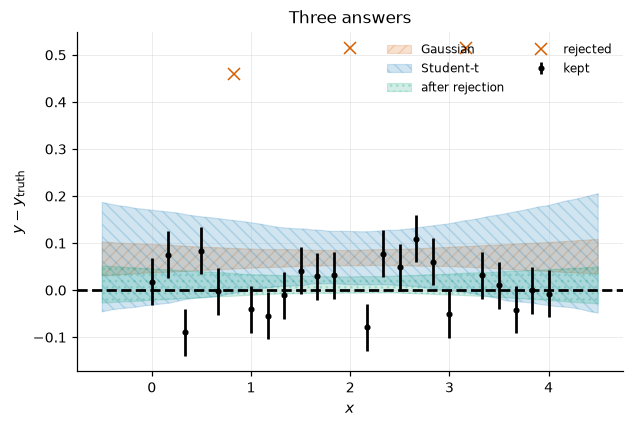

In [15]:
fig, ax = plt.subplots()
for name, p, s, colour, hatch in (
    ("Gaussian", p_gauss, s_gauss, plotstyle.COLOURS[1], plotstyle.HATCHES[0]),
    ("Student-t", p_t, s_t, plotstyle.COLOURS[0], plotstyle.HATCHES[1]),
    ("after rejection", p_reject, s_reject, plotstyle.COLOURS[2], plotstyle.HATCHES[2]),
):
    lo, hi = residual_band(p, s)
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=name)
kept = np.flatnonzero(mask)
ax.errorbar(
    data.x[kept],
    (data.y - y_true_data)[kept],
    data.y_err[kept],
    fmt="o",
    ms=3,
    color="k",
    label="kept",
)
ax.plot(
    data.x[~mask],
    (data.y - y_true_data)[~mask],
    "x",
    ms=8,
    color=plotstyle.COLOURS[1],
    label="rejected",
)
ax.axhline(0.0, ls="--", color="k")
ax.set(xlabel="$x$", ylabel=r"$y - y_\mathrm{truth}$", title="Three answers")
ax.legend(fontsize=8, ncol=2)
plt.show()

Watch the first round: it rejects *four* points, not three.  That first fit is
still being dragged upwards by the outliers, so a perfectly good point at
$x = 0.33$ looks discrepant as well — and once the three real outliers are gone,
the second round puts it straight back.  This is exactly why the procedure is a
loop and not a single pass, and why it is worth printing the history rather than
only the final mask.

At convergence it has found exactly the three points we planted, and the fit
that follows is both centred on the truth and *tight*: $b = 0.512 \pm 0.021$
against the Student-t's $0.566 \pm 0.067$, because it is fitting twenty-two good
points with their honest errors rather than twenty-five points with a tail.

That tightness is the thing to be careful about.  Rejection is a strong claim:
we are asserting that those points are not measurements of this signal, and the
uncertainty we report afterwards does not include the possibility that we were
wrong about that.  The Student-t makes the weaker claim and pays for it with
width.  Which is right is a question about the experiment, not about the
statistics — and if we cannot answer it, the honest thing is to report both,
score them by holding data out (recipe 11), and say what we did.

## Takeaways

- The likelihood functional is a choice, independent of the covariance.  Same
  constraint, same $\chi^2$; `rx.StudentT(nu)` just reads it differently.
- The Student-t does not reject anything.  It widens, and the posterior of
  $\nu$ tells us how much tail the data demanded.
- Rejection is the other answer, and it is an *outer loop* of problems with the
  mask refit between rounds (recipe 39).  It gives the tightest result and makes
  the strongest assumption.
- If what we actually doubt is the size of the reported errors rather than the
  points themselves, that is a different model: see `error_scale_and_usu`.